# Facial Emotion Detection

## Context

Deep Learning has found applications in many predictive tasks relating to more unstructured forms of data over the last few years, such as images, text, audio and video. Many of these tasks seem to be in the vein of a larger direction of predictive modeling that aims to match human-level performance on such tasks, because humans have evolved to specialize in performing intelligent actions on such unstructured data. As a specific branch of AI (also called Affective Computing or Emotion AI) Artificial Emotional Intelligence stands for the study and development of technologies and computers that can read human emotions by means of analyzing body gestures, facial expressions, voice tone, etc. and react appropriately to them.

In the field of human-machine interaction, facial expression recognition is critical. From recent research, it has been found that as much as 55% of communication of sentiment takes place through facial expressions and other visual cues. Therefore, training a model to identify facial emotions accurately is an important step towards the development of emotionally intelligent behavior in machines with AI capabilities. Automatic facial expression recognition systems could have many applications, including but not limited to any use case that requires human behavior understanding, detection of mental disorders, and creating a higher quality of virtual assistant for customer-facing businesses.

## Objective

The goal of this project is to use Deep Learning and Artificial Intelligence techniques to create a computer vision model that can accurately detect facial emotions. The model should be able to perform multi-class classification on images of facial expressions, to classify the expressions according to the associated emotion.

## Dataset

The dataset consists of 20,214 grayscale face images of 48x48 pixels in 3 folders: `train` (15,109 images), `validation` (4,977) and `test` (128). Each of these folders has four subfolders:

- `happy`: Images of people who have happy facial expressions.
- `neutral`: Images of people showing no prominent emotion in their facial expression at all.
- `sad`: Images of people with sad or upset facial expressions.
- `surprise`: Images of people who have shocked or surprised facial expressions.

The three folders are used as they come:

- **Train** fits the models.
- **Validation** decides when to stop training, which hyperparameters to use and which model to keep, so validation scores are slightly optimistic.
- **Test** is used once, at the very end, to score the chosen model on images that played no part in any decision.

## Setup

The dataset folder is read from the `EMOTION_DATA_DIR` environment variable, with a default location in the home directory.

In [1]:
import os
from pathlib import Path

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from cycler import cycler
from keras import layers
from matplotlib.colors import LinearSegmentedColormap
from sklearn import metrics

SEED = 42
keras.utils.set_random_seed(SEED)  # Seeds Python, NumPy and TensorFlow
tf.get_logger().setLevel("ERROR")  # Hides the retracing warnings TensorFlow logs when several models call predict

# The folder that holds train/, validation/ and test/
DATA_DIR = Path(
    os.environ.get("EMOTION_DATA_DIR", Path.home() / "Documents/workspace/Tensorflow/data/Facial_emotion_images")
)
MODEL_DIR = Path("models")
TUNER_DIR = Path("keras_tuner_emotion")

CLASS_NAMES = ["happy", "neutral", "sad", "surprise"]
IMG_SIZE = 48  # The images are 48x48 pixels
TRANSFER_IMG_SIZE = 64  # Images are upscaled to this size for the pretrained backbones
BATCH_SIZE = 64
MAX_EPOCHS = 40  # Upper bound; early stopping can end training sooner
HEAD_EPOCHS = 6  # Transfer learning, phase 1: train the new classifier
FINE_TUNE_EPOCHS = 8  # Transfer learning, phase 2: fine-tune the top block of the backbone
TUNING_MAX_EPOCHS = 9  # Most epochs Hyperband gives a single configuration

# Colorblind-safe categorical order (slot 1 = train, slot 2 = validation) and a one-hue sequential ramp
plt.rcParams["axes.prop_cycle"] = cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"])
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "blue", ["#ffffff", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

print(f"TensorFlow {tf.__version__} | Keras {keras.__version__} | KerasTuner {kt.__version__}")

TensorFlow 2.22.0-dev20260809 | Keras 3.15.1 | KerasTuner 1.4.8


## Load the data

The whole dataset is about 80 MB, so each split is loaded into memory once as a NumPy array. The images are loaded in a fixed order (`shuffle=False`), so an image and its label always sit at the same index. Keras shuffles the training arrays itself at the start of every epoch.

Pixel values stay in their original 0-255 range here. Each model rescales its own input, which keeps the saved models self-contained.

In [2]:
def load_split(split):
    dataset = keras.utils.image_dataset_from_directory(
        DATA_DIR / split,
        class_names=CLASS_NAMES,
        color_mode="grayscale",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=None,
        shuffle=False,
        verbose=False,
    )
    images, labels = zip(*dataset.as_numpy_iterator())
    return np.stack(images), np.array(labels)


x_train, y_train = load_split("train")
x_val, y_val = load_split("validation")
x_test, y_test = load_split("test")

for name, x in [("Train", x_train), ("Validation", x_val), ("Test", x_test)]:
    print(f"{name:10s}: {len(x):6,d} images of shape {x.shape[1:]}, pixel values {x.min():.0f}-{x.max():.0f}")

Train     : 15,109 images of shape (48, 48, 1), pixel values 0-255
Validation:  4,977 images of shape (48, 48, 1), pixel values 0-255
Test      :    128 images of shape (48, 48, 1), pixel values 0-255


## Explore the data

### Class balance

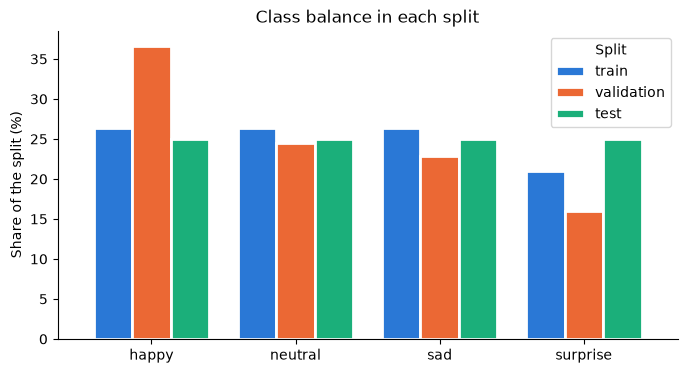

,train,validation,test,train_share
happy,3976,1825,32,0.263
neutral,3978,1216,32,0.263
sad,3982,1139,32,0.264
surprise,3173,797,32,0.210


In [3]:
counts = pd.DataFrame(
    {split: np.bincount(y, minlength=len(CLASS_NAMES)) for split, y in [("train", y_train), ("validation", y_val), ("test", y_test)]},
    index=CLASS_NAMES,
)

ax = (100 * counts / counts.sum()).plot.bar(figsize=(8, 4), rot=0, width=0.8, edgecolor="white", linewidth=2)
ax.set_title("Class balance in each split")
ax.set_ylabel("Share of the split (%)")
ax.legend(title="Split")
plt.show()

counts.assign(train_share=(counts["train"] / counts["train"].sum()).round(3))

**Observations:**

- The training set is close to balanced: happy, neutral and sad have almost the same number of images, and surprise has about 20% fewer. No class weights or resampling are needed.
- The validation set is less balanced: 37% of its images are happy and 16% are surprise. Always answering "happy" would already score 37% accuracy there, so the models are also compared on balanced accuracy (the mean of the per-class recalls) and macro-averaged F1, which weight the four classes equally.
- The test set is perfectly balanced but small, with 32 images per class.

### Sample images

Eight random training images per class.

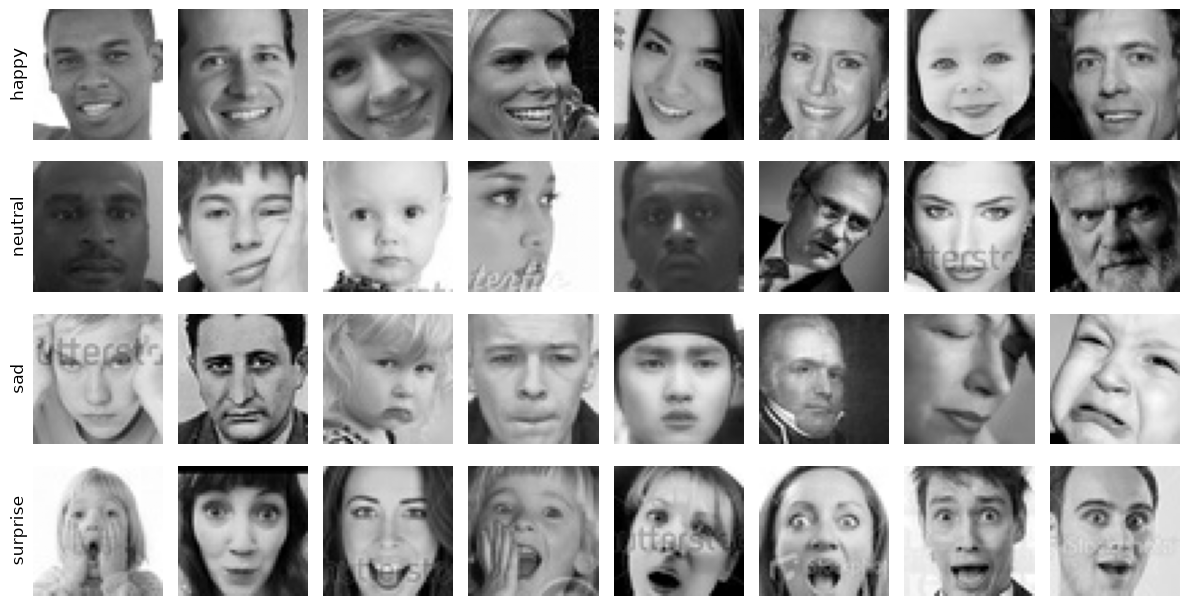

In [4]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(CLASS_NAMES), 8, figsize=(12, 6.3))
for label, (class_name, row) in enumerate(zip(CLASS_NAMES, axes)):
    for ax, idx in zip(row, rng.choice(np.flatnonzero(y_train == label), size=len(row), replace=False)):
        ax.imshow(x_train[idx].squeeze(), cmap="gray", vmin=0, vmax=255)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines[:].set_visible(False)
    row[0].set_ylabel(class_name, fontsize=12)
fig.tight_layout()
plt.show()

**Observations:**

- **Happy:** A smile is a reliable indicator of happiness. Most eyes of the happy sample images are open wide.
- **Neutral:** Many of the people in the neutral images are simply looking ahead without distinctive facial reactions.
- **Sad:** Tears are a reliable indicator of sadness. Closing or squinting the eyes may indicate an attempt to hold back negative emotions such as sadness.
- **Surprise:** An open mouth seems to be a common feature of surprise. Hands on the face or raised in the air may also indicate surprise.
- Some images carry stock-photo watermarks, and some faces are turned away from the camera or partly covered by hands.

Happy and surprise have the most distinctive features. Neutral and sad look alike in many images, so they are likely to be the hardest pair to separate.

## Modeling approach

**Why convolutional networks?** The cues above (a smile, an open mouth, raised eyebrows) are small local patterns that can appear anywhere in the image. A convolutional layer learns a pattern once and detects it at every position, and pooling makes the result tolerant to small shifts. A fully connected network would have to learn the same pattern separately for every position, with far more weights.

**Why grayscale?** The files are single-channel images. Loading them as RGB only copies that channel three times, which adds no information, so the custom CNNs take one channel. The pretrained backbones need three channels, so for those the copy is made inside the model.

Six models are compared on the validation set:

1. a small baseline CNN,
2. a deeper CNN with batch normalization, LeakyReLU and data augmentation,
3. three ImageNet-pretrained backbones (VGG16, ResNet50V2 and EfficientNetV2B0) with a new classifier on top,
4. the deeper CNN again, with hyperparameters chosen by a Hyperband search.

## Training and evaluation helpers

Every model is trained and scored the same way:

- **Loss and optimizer:** sparse categorical cross-entropy on a softmax output, with the Adam optimizer.
- **Early stopping** ends training once the validation loss hasn't improved for 6 epochs and restores the weights from the best epoch, so the evaluated model is the best one and not the last one.
- **`ReduceLROnPlateau`** halves the learning rate when the validation loss stalls for 3 epochs.
- **Evaluation** predicts on the validation array and compares with the label array. Both are in the same fixed order, so predictions and labels always line up.

In [5]:
def compile_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )


def make_callbacks(patience=6):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ]


def fit_model(model, train_inputs=x_train, val_inputs=x_val, epochs=MAX_EPOCHS, patience=6):
    return model.fit(
        train_inputs,
        y_train,
        validation_data=(val_inputs, y_val),
        batch_size=BATCH_SIZE,
        epochs=epochs,
        callbacks=make_callbacks(patience),
        verbose=2,
    )


def plot_history(title, *histories):
    # Several histories (the two transfer-learning phases) are drawn end to end
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    boundaries = np.cumsum([len(history.history["loss"]) for history in histories])[:-1]
    for ax, metric in zip(axes, ["loss", "accuracy"]):
        train = np.concatenate([history.history[metric] for history in histories])
        val = np.concatenate([history.history[f"val_{metric}"] for history in histories])
        epochs = np.arange(1, len(train) + 1)
        ax.plot(epochs, train, linewidth=2, label="Train")
        ax.plot(epochs, val, linewidth=2, label="Validation")
        for boundary in boundaries:
            ax.axvline(boundary + 0.5, color="#8a8a86", linewidth=1, linestyle="--")
        ax.set_title(f"{title}: {metric}")
        ax.set_xlabel("Epoch")
        ax.xaxis.get_major_locator().set_params(integer=True)
        ax.legend()
    fig.tight_layout()
    plt.show()

In [6]:
results = {}  # Validation metrics of every model
trained_models = {}


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": metrics.accuracy_score(y_true, y_pred),
        "balanced_accuracy": metrics.balanced_accuracy_score(y_true, y_pred),
        "macro_f1": metrics.f1_score(y_true, y_pred, average="macro"),
    }


def show_report(title, y_true, y_pred):
    labels = np.arange(len(CLASS_NAMES))
    print(metrics.classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES, digits=3, zero_division=0))
    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    metrics.ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=labels,
        display_labels=CLASS_NAMES,
        normalize="true",
        values_format=".2f",
        cmap=SEQUENTIAL_CMAP,
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{title}\nconfusion matrix (rows normalized by true class)")
    plt.show()


def evaluate_on_validation(name, model):
    y_pred = model.predict(x_val, batch_size=256, verbose=0).argmax(axis=1)
    results[name] = compute_metrics(y_val, y_pred)
    trained_models[name] = model
    show_report(f"{name}, validation set", y_val, y_pred)

## Baseline CNN

Three convolution and max-pooling blocks, followed by one hidden dense layer with dropout. It is trained without augmentation, as a reference point for the models that follow.

In [7]:
def build_baseline_cnn():
    model = keras.Sequential(
        [
            keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
            layers.Rescaling(1 / 255),
            layers.Conv2D(32, 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(128, 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Flatten(),
            layers.Dense(128, activation="silu"),
            layers.Dropout(0.5),
            layers.Dense(len(CLASS_NAMES), activation="softmax"),
        ],
        name="baseline_cnn",
    )
    compile_model(model, learning_rate=1e-3)
    return model


keras.utils.set_random_seed(SEED)
baseline_cnn = build_baseline_cnn()
baseline_cnn.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,460 (1.36 MB)

 Trainable params: 355,460 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40


237/237 - 26s - 111ms/step - accuracy: 0.4445 - loss: 1.2073 - val_accuracy: 0.5455 - val_loss: 1.0724 - learning_rate: 0.0010


Epoch 2/40


237/237 - 30s - 126ms/step - accuracy: 0.5871 - loss: 0.9724 - val_accuracy: 0.6409 - val_loss: 0.8673 - learning_rate: 0.0010


Epoch 3/40


...

237/237 - 28s - 118ms/step - accuracy: 0.8061 - loss: 0.4956 - val_accuracy: 0.7052 - val_loss: 0.7877 - learning_rate: 5.0000e-04


Epoch 11/40


237/237 - 28s - 119ms/step - accuracy: 0.8216 - loss: 0.4638 - val_accuracy: 0.7056 - val_loss: 0.8061 - learning_rate: 5.0000e-04


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 5.


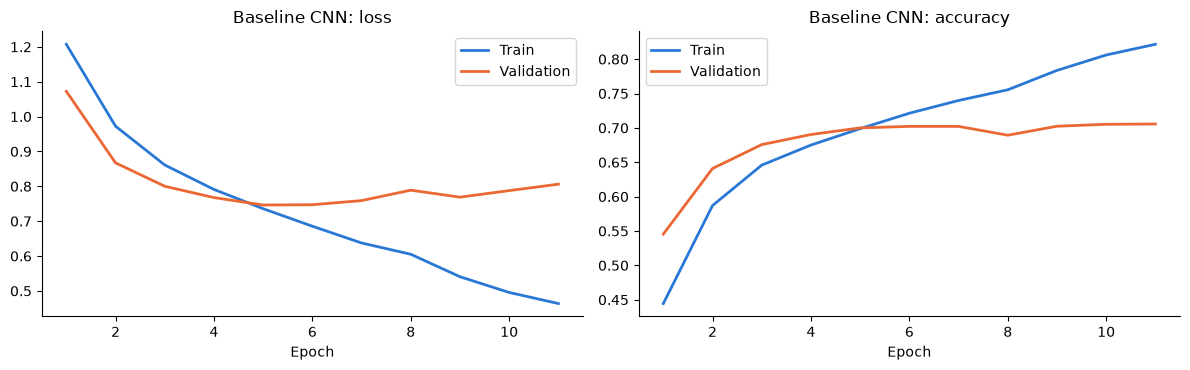

              precision    recall  f1-score   support

       happy      0.789     0.819     0.804      1825
     neutral      0.594     0.633     0.613      1216
         sad      0.597     0.540     0.567      1139
    surprise      0.799     0.758     0.778       797

    accuracy                          0.700      4977
   macro avg      0.695     0.688     0.690      4977
weighted avg      0.699     0.700     0.699      4977



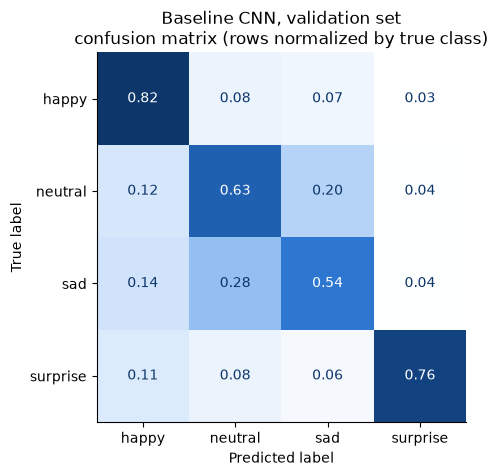

In [8]:
baseline_history = fit_model(baseline_cnn)
plot_history("Baseline CNN", baseline_history)
evaluate_on_validation("Baseline CNN", baseline_cnn)

**Observations:**

- The baseline reaches 0.700 validation accuracy and 0.690 macro-F1 after only 5 epochs.
- It then overfits: training accuracy keeps climbing, to 0.82 by epoch 11, while the validation loss rises from 0.75 to 0.81. Early stopping ends training and restores the weights from epoch 5.
- Happy and surprise are recognized best (F1 0.80 and 0.78). Sad is the hardest class (recall 0.54): 28% of the sad faces are predicted as neutral, and 20% of the neutral faces as sad.

## Deeper CNN with batch normalization and augmentation

The second model is built from repeated blocks of convolution, batch normalization, LeakyReLU, max-pooling and dropout, with the number of filters doubling from block to block (capped at 256). Two things are new compared with the baseline:

- **Data augmentation.** Each training image is randomly flipped left to right, rotated by up to 18 degrees, zoomed by up to 10% and shifted by up to 10% before it reaches the network. A mirrored or slightly tilted face shows the same emotion, so the model sees a different version of every image in every epoch, which makes memorizing the training set much harder. The augmentation layers are only active during training.
- **Batch normalization** after every convolution, which keeps the activations in a stable range and allows the learning rate of 0.001.

The builder takes a Keras Tuner `HyperParameters` object. Every hyperparameter has its own name and a default value, so the same function builds this model (from the defaults) and the candidates of the search further down. The output layer is always a softmax, which is what the cross-entropy loss expects.

In [9]:
def augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.1, 0.1),
        ],
        name="augmentation",
    )


def build_cnn(hp):
    num_blocks = hp.Int("num_blocks", min_value=3, max_value=5, default=4)
    base_filters = hp.Choice("base_filters", [16, 24, 32], default=32)
    conv_dropout = hp.Float("conv_dropout", min_value=0.0, max_value=0.3, step=0.1, default=0.2)
    dense_units = hp.Choice("dense_units", [128, 256, 512], default=256)
    dense_dropout = hp.Float("dense_dropout", min_value=0.2, max_value=0.5, step=0.1, default=0.4)
    learning_rate = hp.Float("learning_rate", min_value=3e-4, max_value=3e-3, sampling="log", default=1e-3)

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = augmentation()(inputs)
    x = layers.Rescaling(1 / 255)(x)
    for block in range(num_blocks):
        x = layers.Conv2D(min(base_filters * 2**block, 256), 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=0.1)(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(conv_dropout)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(dense_dropout)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="cnn")
    compile_model(model, learning_rate)
    return model


keras.utils.set_random_seed(SEED)
default_cnn = build_cnn(kt.HyperParameters())
default_cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 256)      │             

 Total params: 981,156 (3.74 MB)

 Trainable params: 979,684 (3.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/40


237/237 - 86s - 362ms/step - accuracy: 0.3729 - loss: 1.4360 - val_accuracy: 0.3673 - val_loss: 1.5227 - learning_rate: 0.0010


Epoch 2/40


237/237 - 75s - 316ms/step - accuracy: 0.4716 - loss: 1.1939 - val_accuracy: 0.4193 - val_loss: 1.4724 - learning_rate: 0.0010


Epoch 3/40


...

Epoch 39/40


237/237 - 60s - 253ms/step - accuracy: 0.7263 - loss: 0.6763 - val_accuracy: 0.7571 - val_loss: 0.6176 - learning_rate: 3.1250e-05


Epoch 40/40


237/237 - 62s - 261ms/step - accuracy: 0.7279 - loss: 0.6733 - val_accuracy: 0.7537 - val_loss: 0.6246 - learning_rate: 3.1250e-05


Restoring model weights from the end of the best epoch: 39.


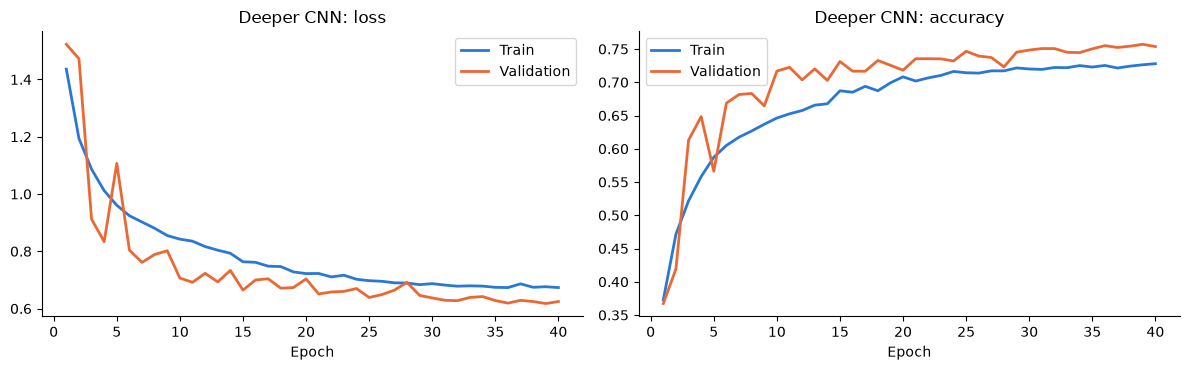

              precision    recall  f1-score   support

       happy      0.887     0.825     0.855      1825
     neutral      0.630     0.719     0.672      1216
         sad      0.686     0.607     0.644      1139
    surprise      0.787     0.875     0.828       797

    accuracy                          0.757      4977
   macro avg      0.748     0.756     0.750      4977
weighted avg      0.762     0.757     0.758      4977



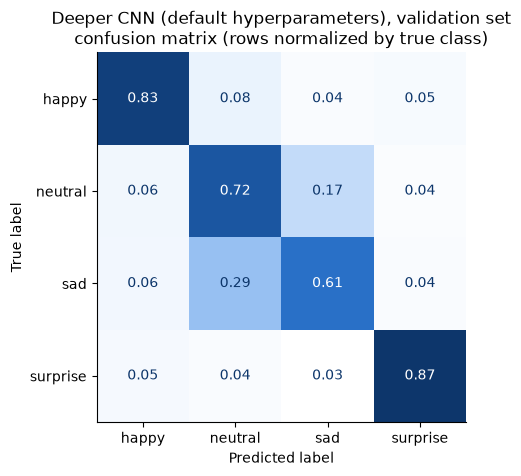

In [10]:
default_history = fit_model(default_cnn)
plot_history("Deeper CNN", default_history)
evaluate_on_validation("Deeper CNN (default hyperparameters)", default_cnn)

**Observations:**

- Augmentation and batch normalization add almost 6 points over the baseline: 0.757 validation accuracy and 0.750 macro-F1.
- There is no overfitting. Training accuracy stays below validation accuracy the whole time (0.73 against 0.75 at the end), because dropout and augmentation are only active during training, so the training images are the harder, perturbed versions.
- The model used all 40 epochs and its best epoch was the 39th, but the gains had become small: the learning rate was down to 0.00003 and the last 15 epochs added about 1 point.
- Neutral and sad are still the pair the model mixes up most: 29% of the sad faces are predicted as neutral and 17% of the neutral faces as sad. Happy and surprise are recognized 83% and 87% of the time.

## Transfer learning

VGG16, ResNet50V2 and EfficientNetV2B0 were trained on ImageNet: 224x224 color photographs of objects. To reuse them on 48x48 grayscale faces, each model does the following:

1. **Resize** the image to 64x64. The backbones shrink their input by a factor of 32, so a 48x48 image would leave almost nothing to pool over. Larger sizes may work better but cost more: 64 keeps the whole notebook runnable on a CPU, and `TRANSFER_IMG_SIZE` can be raised on a GPU.
2. **Copy the channel** three times, because the backbones expect RGB.
3. **Apply the backbone's own `preprocess_input`**, since each network expects the pixel scaling it was trained with: VGG16 subtracts the ImageNet channel means from 0-255 values, ResNet50V2 scales to [-1, 1], and EfficientNetV2 does its scaling internally and takes raw 0-255 values.
4. **Classify** with global average pooling, batch normalization, dropout and a single softmax layer. The batch normalization layer is there because the pooled features of the three backbones have very different scales.

Training has two phases:

- **Phase 1:** the whole backbone is frozen and only the new classifier is trained, with a learning rate of 0.001.
- **Phase 2:** the top block of the backbone (block 5 of VGG16, stage 5 of ResNet50V2, block 6 onwards of EfficientNetV2B0) is unfrozen and fine-tuned together with the classifier, with a learning rate of 0.00001. Such a small learning rate adjusts the pretrained weights without destroying them. The batch normalization layers of that block stay frozen. A frozen batch normalization layer runs in inference mode, so it keeps using its ImageNet statistics. Unfrozen, it would switch to the statistics of each training batch, which shifts the features that the layers above it expect and can undo much of the pretraining.

Each phase stops early after 3 epochs without a better validation loss.

The lower part of each backbone, the *trunk*, stays frozen in both phases. Its output for a given image never changes, so it is computed once and both phases train on the cached features. This is what makes three pretrained networks affordable on a CPU. The price is that the transfer models are trained without data augmentation, since augmented images would need a fresh pass through the trunk in every epoch.

After training, the trunk and the trained part are joined into one model that takes a 48x48 grayscale image, and that model is evaluated like all the others. The much larger EfficientNetV2L is replaced by EfficientNetV2B0: 118 million parameters are far more than 15,000 small training images can support.

In [11]:
BACKBONES = {
    "VGG16": {
        "application": keras.applications.VGG16,
        "preprocess": keras.applications.vgg16.preprocess_input,
        "cut_layer": "block4_pool",  # Block 5 is fine-tuned
    },
    "ResNet50V2": {
        "application": keras.applications.ResNet50V2,
        "preprocess": keras.applications.resnet_v2.preprocess_input,
        "cut_layer": "conv4_block6_out",  # Stage 5 is fine-tuned
    },
    "EfficientNetV2B0": {
        "application": keras.applications.EfficientNetV2B0,
        "preprocess": keras.applications.efficientnet_v2.preprocess_input,
        "cut_layer": "block5e_add",  # Block 6 and the top convolution are fine-tuned
    },
}


def split_backbone(name):
    # Returns the frozen trunk (grayscale image -> features at the cut) and the top block (features -> backbone output)
    config = BACKBONES[name]
    backbone = config["application"](
        include_top=False, weights="imagenet", input_shape=(TRANSFER_IMG_SIZE, TRANSFER_IMG_SIZE, 3)
    )
    backbone.trainable = False
    cut = backbone.get_layer(config["cut_layer"]).output

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Resizing(TRANSFER_IMG_SIZE, TRANSFER_IMG_SIZE)(inputs)
    x = layers.Concatenate()([x, x, x])
    x = config["preprocess"](x)
    x = keras.Model(backbone.input, cut)(x)
    trunk = keras.Model(inputs, x, name=f"{name}_trunk")
    top_block = keras.Model(cut, backbone.output, name=f"{name}_top_block")
    return trunk, top_block


def count_trainable(model):
    return sum(int(np.prod(weight.shape)) for weight in model.trainable_weights)


def train_transfer_model(name):
    keras.utils.set_random_seed(SEED)
    trunk, top_block = split_backbone(name)

    # The trunk is never trained, so its features are computed once
    train_features = trunk.predict(x_train, batch_size=256, verbose=0)
    val_features = trunk.predict(x_val, batch_size=256, verbose=0)

    inputs = keras.Input(shape=train_features.shape[1:])
    x = top_block(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)  # Puts the pooled features of every backbone on the same scale
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)
    classifier = keras.Model(inputs, outputs, name=f"{name}_classifier")

    print(f"Phase 1: train the new classifier on the frozen backbone ({count_trainable(classifier):,d} trainable weights)")
    compile_model(classifier, learning_rate=1e-3)
    head_history = fit_model(classifier, train_features, val_features, epochs=HEAD_EPOCHS, patience=3)

    # Batch normalization layers stay frozen: a frozen one runs in inference mode and keeps its ImageNet statistics
    for layer in top_block.layers:
        layer.trainable = not isinstance(layer, layers.BatchNormalization)
    print(f"Phase 2: fine-tune the top block as well ({count_trainable(classifier):,d} trainable weights)")
    compile_model(classifier, learning_rate=1e-5)
    fine_tune_history = fit_model(classifier, train_features, val_features, epochs=FINE_TUNE_EPOCHS, patience=3)

    # Image in, class probabilities out
    model = keras.Sequential([trunk, classifier], name=name)
    plot_history(name, head_history, fine_tune_history)
    evaluate_on_validation(name, model)
    return model

### VGG16

In the training curves of the transfer models, the dashed line marks the switch from phase 1 to phase 2.

Phase 1: train the new classifier on the frozen backbone (3,076 trainable weights)


Epoch 1/6


237/237 - 47s - 200ms/step - accuracy: 0.4134 - loss: 1.4739 - val_accuracy: 0.5345 - val_loss: 1.1572 - learning_rate: 0.0010


Epoch 2/6


237/237 - 46s - 193ms/step - accuracy: 0.5134 - loss: 1.1641 - val_accuracy: 0.5736 - val_loss: 1.0708 - learning_rate: 0.0010


...

Epoch 7/8


237/237 - 170s - 717ms/step - accuracy: 0.7836 - loss: 0.5741 - val_accuracy: 0.7103 - val_loss: 0.7451 - learning_rate: 1.0000e-05


Epoch 8/8


237/237 - 196s - 828ms/step - accuracy: 0.8039 - loss: 0.5359 - val_accuracy: 0.7117 - val_loss: 0.7446 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 8.


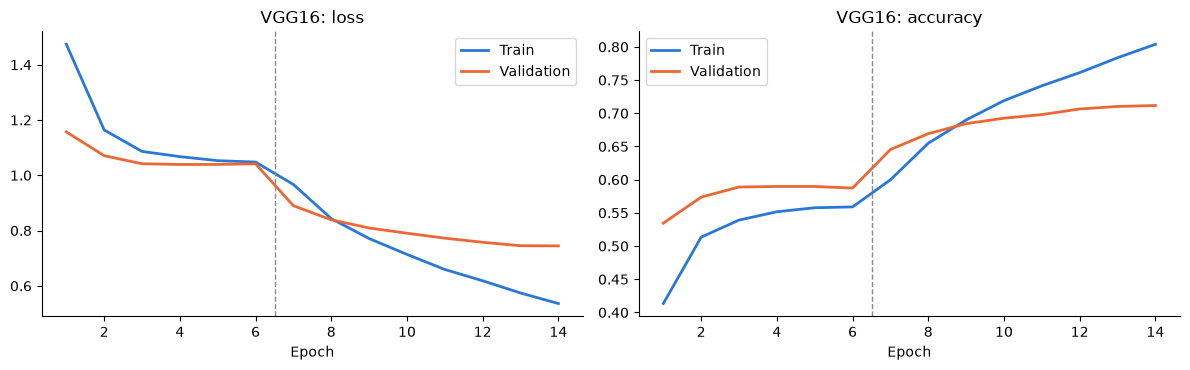

              precision    recall  f1-score   support

       happy      0.851     0.759     0.803      1825
     neutral      0.597     0.662     0.628      1216
         sad      0.614     0.609     0.611      1139
    surprise      0.756     0.824     0.789       797

    accuracy                          0.712      4977
   macro avg      0.704     0.714     0.708      4977
weighted avg      0.719     0.712     0.714      4977



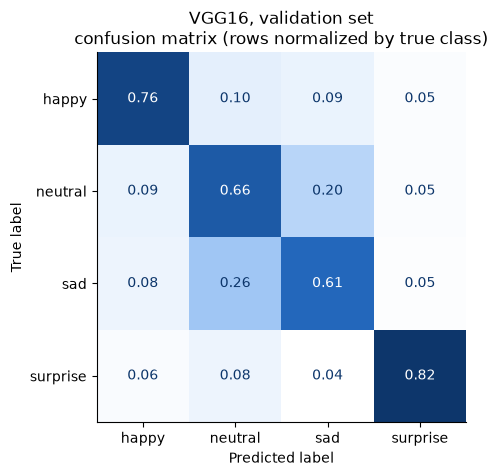

In [12]:
vgg16_model = train_transfer_model("VGG16")

### ResNet50V2

Phase 1: train the new classifier on the frozen backbone (12,292 trainable weights)
Epoch 1/6


237/237 - 32s - 135ms/step - accuracy: 0.4579 - loss: 1.3812 - val_accuracy: 0.5216 - val_loss: 1.1302 - learning_rate: 0.0010


Epoch 2/6


237/237 - 30s - 126ms/step - accuracy: 0.5393 - loss: 1.1245 - val_accuracy: 0.5544 - val_loss: 1.0838 - learning_rate: 0.0010


Epoch 3/6


...

Epoch 7/8


237/237 - 267s - 1s/step - accuracy: 0.8993 - loss: 0.3501 - val_accuracy: 0.6548 - val_loss: 0.8952 - learning_rate: 1.0000e-05


Epoch 8/8


237/237 - 214s - 903ms/step - accuracy: 0.9238 - loss: 0.2972 - val_accuracy: 0.6548 - val_loss: 0.8921 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 8.


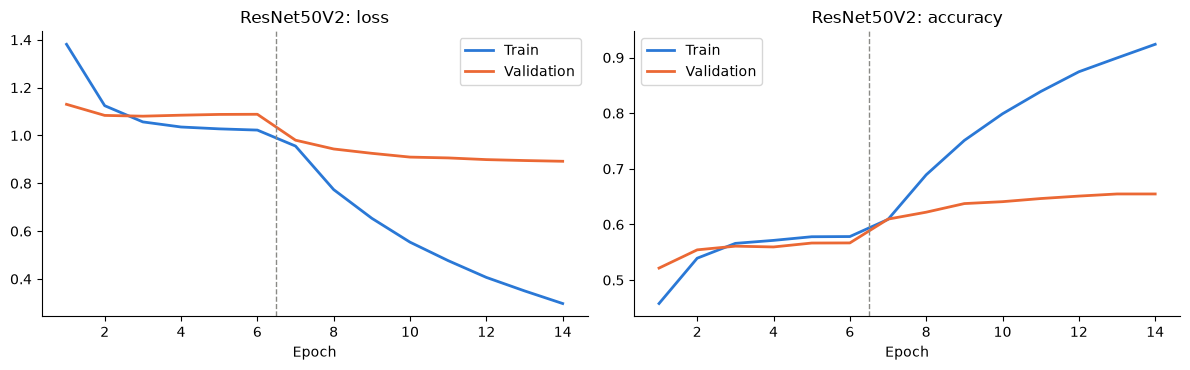

              precision    recall  f1-score   support

       happy      0.753     0.741     0.747      1825
     neutral      0.544     0.530     0.537      1216
         sad      0.558     0.561     0.559      1139
    surprise      0.733     0.780     0.756       797

    accuracy                          0.655      4977
   macro avg      0.647     0.653     0.650      4977
weighted avg      0.654     0.655     0.654      4977



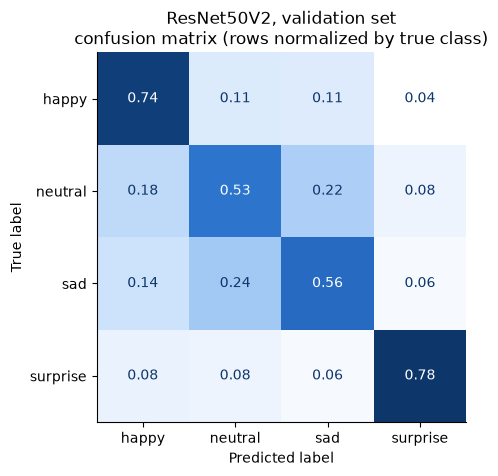

In [13]:
resnet_model = train_transfer_model("ResNet50V2")

### EfficientNetV2B0

Phase 1: train the new classifier on the frozen backbone (7,684 trainable weights)
Epoch 1/6


237/237 - 26s - 110ms/step - accuracy: 0.4729 - loss: 1.3700 - val_accuracy: 0.5821 - val_loss: 1.0300 - learning_rate: 0.0010


Epoch 2/6


237/237 - 18s - 77ms/step - accuracy: 0.5519 - loss: 1.0925 - val_accuracy: 0.6074 - val_loss: 0.9619 - learning_rate: 0.0010


Epoch 3/6


...

Epoch 7/8


237/237 - 48s - 201ms/step - accuracy: 0.6885 - loss: 0.7694 - val_accuracy: 0.6641 - val_loss: 0.8221 - learning_rate: 1.0000e-05


Epoch 8/8


237/237 - 82s - 346ms/step - accuracy: 0.6922 - loss: 0.7569 - val_accuracy: 0.6689 - val_loss: 0.8110 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 8.


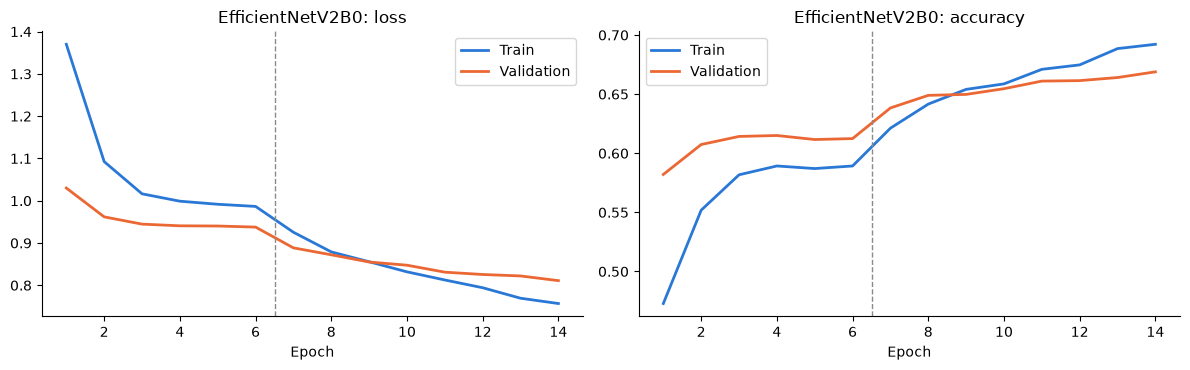

              precision    recall  f1-score   support

       happy      0.750     0.779     0.764      1825
     neutral      0.588     0.516     0.549      1216
         sad      0.567     0.574     0.570      1139
    surprise      0.727     0.787     0.756       797

    accuracy                          0.669      4977
   macro avg      0.658     0.664     0.660      4977
weighted avg      0.665     0.669     0.666      4977



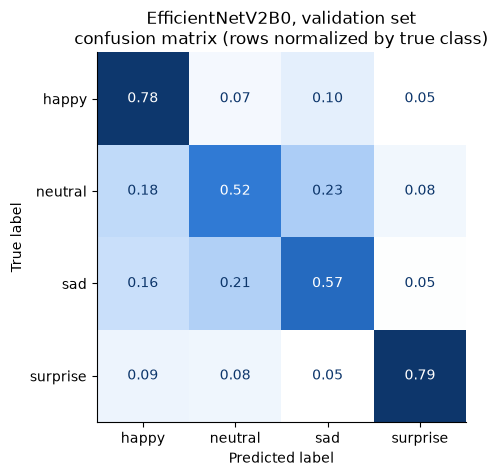

In [14]:
efficientnet_model = train_transfer_model("EfficientNetV2B0")

**Observations:**

| Backbone | Frozen (phase 1) | Fine-tuned (phase 2) | Macro-F1 | Parameters |
|---|---|---|---|---|
| VGG16 | 0.590 | 0.712 | 0.708 | 14.7 M |
| ResNet50V2 | 0.561 | 0.655 | 0.650 | 23.6 M |
| EfficientNetV2B0 | 0.612 | 0.669 | 0.660 | 5.9 M |

The two accuracy columns are validation accuracy.

- None of the pretrained backbones beats the deeper CNN (0.757), which has 6 to 24 times fewer parameters. Only VGG16 does better than the baseline CNN.
- The frozen ImageNet features on their own reach only 0.56-0.61. Features learned from color photographs of objects don't carry over well to 48x48 grayscale faces. Fine-tuning the top block is what makes these models useful, adding 6 to 12 points.
- ResNet50V2 overfits badly during fine-tuning: training accuracy reaches 0.92 against 0.655 on validation. Its top block has 15 million trainable weights and, with cached features, no augmentation.
- All three were still improving when fine-tuning reached its 8-epoch limit, so more epochs, augmentation and larger input images would probably narrow the gap. Each of those makes training much slower on a CPU.

## Tune the CNN

The search covers six hyperparameters of `build_cnn`: the number of blocks, the number of filters, both dropout rates, the width of the dense layer and the learning rate.

Hyperband trains many configurations for a few epochs and gives more epochs only to the most promising ones, which is far cheaper than training every configuration to the end. With `max_epochs=9` it tries 17 configurations in about 75 epochs of training in total. The objective is validation accuracy.

Results are saved to `keras_tuner_emotion/`. Because of `overwrite=False`, running this cell again reloads the finished search instead of starting over. Delete that folder after changing the search space.

In [15]:
tuner = kt.Hyperband(
    build_cnn,
    objective="val_accuracy",
    max_epochs=TUNING_MAX_EPOCHS,
    factor=3,
    seed=SEED,
    directory=TUNER_DIR,
    project_name="cnn",
    overwrite=False,
)
tuner.search(x_train, y_train, validation_data=(x_val, y_val), batch_size=BATCH_SIZE, verbose=2)
tuner.results_summary(num_trials=5)

Reloading Tuner from keras_tuner_emotion/cnn/tuner0.json
Results summary
Results in keras_tuner_emotion/cnn
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 0019 summary
Hyperparameters:
num_blocks: 3
base_filters: 32
conv_dropout: 0.2
dense_units: 128
dense_dropout: 0.4
learning_rate: 0.00253182750284068
tuner/epochs: 9
tuner/initial_epoch: 3
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0016
Score: 0.6962025165557861

Trial 0018 summary
Hyperparameters:
num_blocks: 4
base_filters: 16
conv_dropout: 0.1
dense_units: 256
dense_dropout: 0.2
learning_rate: 0.0011435980001595588
tuner/epochs: 9
tuner/initial_epoch: 3
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0013
Score: 0.6923849582672119

Trial 0021 summary
Hyperparameters:
num_blocks: 4
base_filters: 24
conv_dropout: 0.1
dense_units: 512
dense_dropout: 0.30000000000000004
learning_rate: 0.00035439519829145533
tuner/epochs: 9
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.68294155597686

Hyperband trains its best trial for only 9 epochs, so the best configuration is rebuilt and trained from scratch with the same schedule as the other models.

{'num_blocks': 3, 'base_filters': 32, 'conv_dropout': 0.2, 'dense_units': 128, 'dense_dropout': 0.4, 'learning_rate': 0.00253182750284068}


Epoch 1/40


237/237 - 53s - 226ms/step - accuracy: 0.3955 - loss: 1.3387 - val_accuracy: 0.3814 - val_loss: 1.5047 - learning_rate: 0.0025


Epoch 2/40


237/237 - 52s - 220ms/step - accuracy: 0.4969 - loss: 1.1346 - val_accuracy: 0.4752 - val_loss: 1.2459 - learning_rate: 0.0025


...

237/237 - 51s - 214ms/step - accuracy: 0.7147 - loss: 0.7042 - val_accuracy: 0.7344 - val_loss: 0.6686 - learning_rate: 6.3296e-04


Epoch 28/40


237/237 - 51s - 213ms/step - accuracy: 0.7116 - loss: 0.7022 - val_accuracy: 0.7392 - val_loss: 0.6587 - learning_rate: 6.3296e-04


Epoch 28: early stopping


Restoring model weights from the end of the best epoch: 22.


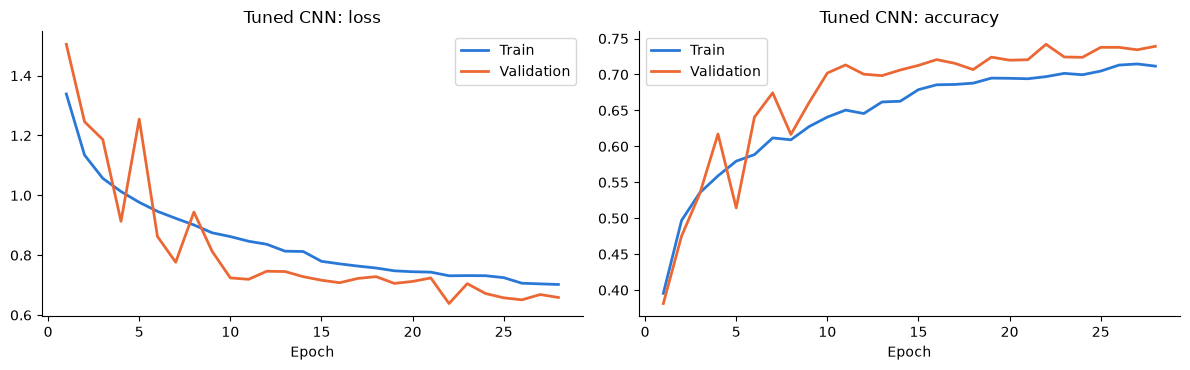

              precision    recall  f1-score   support

       happy      0.864     0.825     0.844      1825
     neutral      0.621     0.668     0.643      1216
         sad      0.665     0.597     0.629      1139
    surprise      0.770     0.872     0.818       797

    accuracy                          0.742      4977
   macro avg      0.730     0.741     0.734      4977
weighted avg      0.744     0.742     0.742      4977



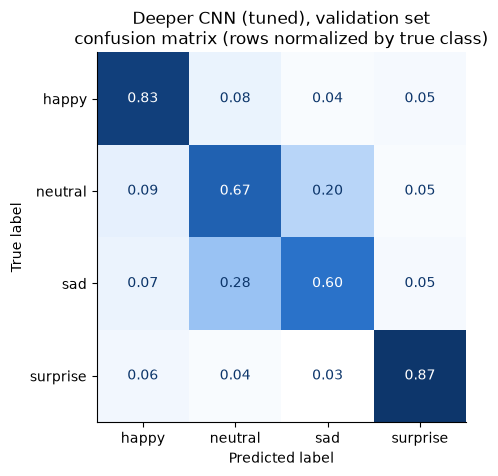

In [16]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print({name: value for name, value in best_hp.values.items() if not name.startswith("tuner/")})

keras.utils.set_random_seed(SEED)
tuned_cnn = build_cnn(best_hp)
tuned_history = fit_model(tuned_cnn)
plot_history("Tuned CNN", tuned_history)
evaluate_on_validation("Deeper CNN (tuned)", tuned_cnn)

**Observations:**

- The best configuration of the search has 3 blocks instead of 4, 32 base filters, a 128-unit dense layer and a learning rate of 0.0025, 2.5 times the default. It has 684,196 parameters.
- Trained in full, it reaches 0.742 validation accuracy and 0.734 macro-F1, slightly *worse* than the default configuration (0.757 and 0.750).
- The reason is the search budget. Hyperband scored every configuration after at most 9 epochs, which rewards models that learn quickly: after 9 epochs the winner scored 0.696, while the default configuration was at 0.665. With the full schedule the default configuration catches up and ends ahead. A search that ranks configurations after longer training (a larger `max_epochs`) is more likely to pick the configuration that ends best, at a much higher cost.

## Compare the models

All models are compared on the full validation set. The model with the highest macro-F1 is kept as the final model.

In [17]:
comparison = pd.DataFrame(results).T.round(3)
comparison["parameters"] = [trained_models[name].count_params() for name in comparison.index]
comparison = comparison.sort_values("macro_f1", ascending=False)

best_name = comparison.index[0]
final_model = trained_models[best_name]
print(f"Best model on the validation set: {best_name}")
comparison

Best model on the validation set: Deeper CNN (default hyperparameters)


,accuracy,balanced_accuracy,macro_f1,parameters
Deeper CNN (default hyperparameters),0.757,0.756,0.750,981156
Deeper CNN (tuned),0.742,0.741,0.734,684196
VGG16,0.712,0.714,0.708,14718788
Baseline CNN,0.700,0.688,0.690,355460
EfficientNetV2B0,0.669,0.664,0.660,5929556
ResNet50V2,0.655,0.653,0.650,23581188


**Observations:**

- The deeper CNN with its default hyperparameters is the best model on all three metrics, and with under 1 million parameters it is far smaller than any of the pretrained models. It is the final model.
- The tuned CNN comes second, and VGG16 is the only pretrained model that beats the baseline.
- The ranking is the same by accuracy, balanced accuracy and macro-F1, so it isn't an artifact of the happy-heavy validation set.

## Evaluate the final model on the test set

The test set has played no part in training, early stopping, tuning or model selection, so this is the unbiased estimate of how the final model does on new images. With only 128 images the estimate is noisy, which the 95% confidence interval makes explicit.

Deeper CNN (default hyperparameters) on the 128 test images
Accuracy: 0.805 +/- 0.069 (95% confidence interval)
Balanced accuracy: 0.805 | Macro F1: 0.807

              precision    recall  f1-score   support

       happy      0.848     0.875     0.862        32
     neutral      0.727     0.750     0.738        32
         sad      0.706     0.750     0.727        32
    surprise      0.964     0.844     0.900        32

    accuracy                          0.805       128
   macro avg      0.811     0.805     0.807       128
weighted avg      0.811     0.805     0.807       128



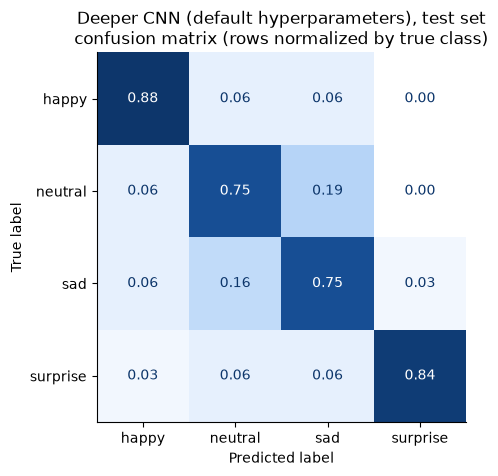

In [18]:
test_pred = final_model.predict(x_test, verbose=0).argmax(axis=1)
test_metrics = compute_metrics(y_test, test_pred)
margin = 1.96 * np.sqrt(test_metrics["accuracy"] * (1 - test_metrics["accuracy"]) / len(y_test))

print(f"{best_name} on the {len(y_test)} test images")
print(f"Accuracy: {test_metrics['accuracy']:.3f} +/- {margin:.3f} (95% confidence interval)")
print(f"Balanced accuracy: {test_metrics['balanced_accuracy']:.3f} | Macro F1: {test_metrics['macro_f1']:.3f}\n")
show_report(f"{best_name}, test set", y_test, test_pred)

Random test images with the predicted label. For wrong predictions, the true label follows in parentheses.

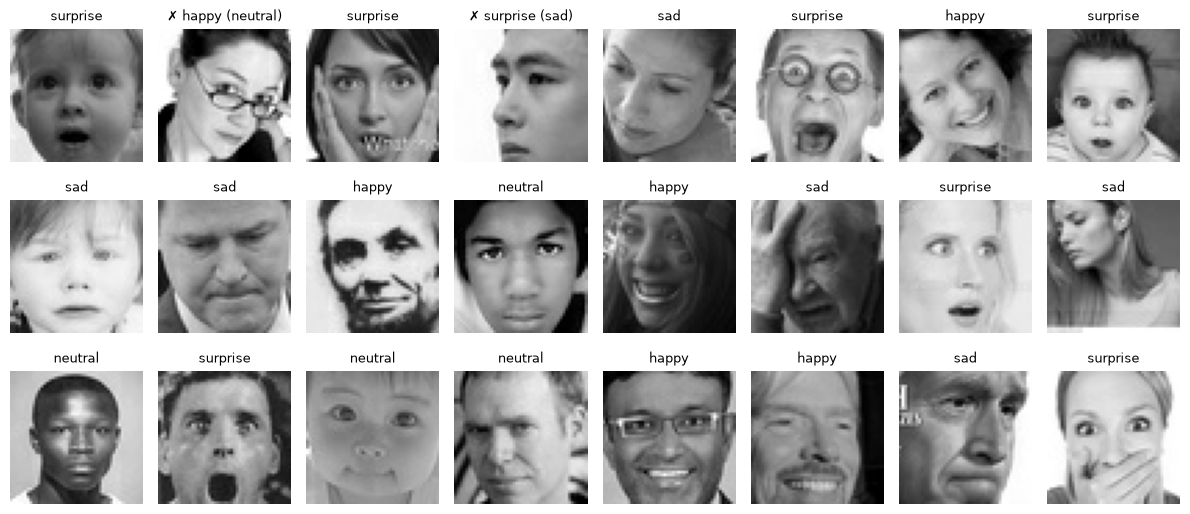

In [19]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(3, 8, figsize=(12, 5.4))
for ax, idx in zip(axes.flat, rng.choice(len(x_test), size=axes.size, replace=False)):
    predicted, actual = CLASS_NAMES[test_pred[idx]], CLASS_NAMES[y_test[idx]]
    ax.imshow(x_test[idx].squeeze(), cmap="gray", vmin=0, vmax=255)
    ax.set_title(predicted if predicted == actual else f"✗ {predicted} ({actual})", fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

## Save the final model

The saved model takes 48x48 grayscale images with pixel values from 0 to 255 and returns the probabilities of the four classes in the order happy, neutral, sad, surprise.

In [20]:
MODEL_DIR.mkdir(exist_ok=True)
final_model.save(MODEL_DIR / "emotion_detection.keras")

## Conclusions

- **Final model:** the deeper CNN with batch normalization, LeakyReLU and data augmentation, using its default hyperparameters. It scores 0.757 accuracy and 0.750 macro-F1 on the validation set, and 0.805 accuracy (95% confidence interval 0.74-0.87) with 0.807 macro-F1 on the 128 held-out test images. The test estimate is higher than the validation one, but with 32 images per class the difference is within the noise.
- **What helped most:** data augmentation with batch normalization. Together they turned a baseline that overfit after 5 epochs (0.700) into a model that kept improving for 40 epochs without overfitting (0.757).
- **What helped less than expected:**
  - *Transfer learning.* ImageNet backbones start from features that fit 48x48 grayscale faces poorly, need fine-tuning to be competitive, and at 6 to 24 times the size they still finished behind the deeper CNN.
  - *Hyperparameter tuning.* A short Hyperband search picked a configuration that learns fast but ends lower than the default one.
- **Remaining errors:** the largest source is neutral versus sad. The two are confused with each other in 16-29% of cases, and these confusions make up over 40% of all mistakes on both the validation and the test set. Happy and surprise are recognized well (recall 0.82-0.88). Some images are hard even for a person: faces turned away, partly covered by hands or watermarked.

**Proposal for the final solution design and next steps:**

- Use the deeper CNN from `models/emotion_detection.keras`. It takes 48x48 grayscale images with values 0-255 and needs no preprocessing outside the model.
- On a GPU, try a wider version (two convolutions per block, 64 base filters) trained for longer, since this model was still improving slowly at 40 epochs.
- Fine-tune the pretrained backbones end to end, with augmentation and larger input images (96-160 pixels), instead of on cached features. That is too slow on a CPU but may close the gap to the CNN.
- Rerun the search with a larger `max_epochs`, so that configurations are compared after training closer to convergence.
- Target the neutral-sad confusion: collect more examples of subtle sadness, review the labels of the most frequently confused images, or combine several models in an ensemble.
- Build a larger test set, or use cross-validation, before relying on the test accuracy: with 128 images its 95% confidence interval is about ±7 points.